**Linear Regression**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

**data collection**

In [2]:
df = sns.load_dataset('tips')
df.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**understand the dataset**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

**Stats sum**

In [5]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


**Relationship check**

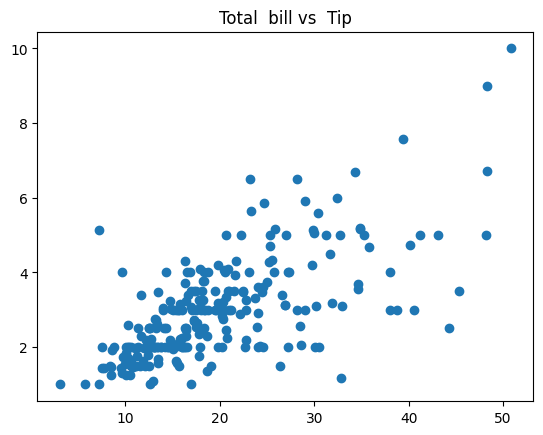

In [6]:
plt.scatter(df['total_bill'],df['tip'])
plt.xlabel = 'total_bill'
plt.ylabel = 'tip'
plt.title("Total  bill vs  Tip")
plt.show()

observations :


*   As the bill increases tip increases
*   relationship=straight line(we can use linear regression)




**Feature and target separation**

In [7]:
x=df[['total_bill']]  #feature i/p in 2d only(imp)
y=df['tip']   #feature o/p 1d


**Train-test split**


*  **why.? -> A model must perform well on unseen data**



In [8]:
x=df[['total_bill']]  #feature i/p in 2d only(imp)
y=df['tip']   #feature o/p 1d
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#80% on training , 20% on testing ., random state is to select data points randomly i,e 42 datapoints.


**feature standardization** -

why..?
*   compare the co-efficients fairly
*   Avoid the dominance of large values
*   Prepare for Ridge/Lasso






In [9]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
x_train_scaled=scalar.fit_transform(x_train)
x_test_scaled=scalar.transform(x_test)
 #imp:
 #Fit only  on training data
 #Prevents the data leakage

**Train linear regression model**

In [16]:
from sklearn.linear_model  import LinearRegression
model=LinearRegression()
model.fit(x_train_scaled,y_train)
print("co-efficient (m):",model.coef_[0])
print("Intercept (c):",model.intercept_)
y_pred=model.predict(x_test_scaled)


co-efficient (m): 0.9357171400271824
Intercept (c): 3.0877948717948724


**Model Evaluation**

In [12]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R2 Score :",r2)

R2 Score : 0.5449381659234664


In [13]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("mse:",mse)
print("rmse:",rmse)

mse: 0.5688142529229537
rmse: 0.7541977545199626


**visulaize the best fit line.**

TypeError: 'str' object is not callable

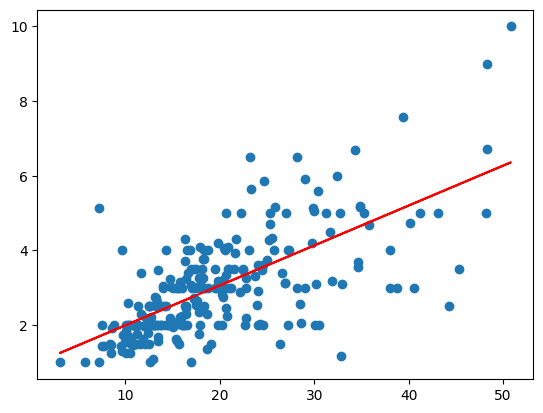

In [14]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.plot(x,model.predict(scalar.transform(x)),color="red")
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.title("Linear regression best fit line")
plt.show()

In [ ]:
# coefficient(m): 0.9357171400271826
# intercept(c): 3.0877948717948724
# R² score: 0.5449381659234664
# Mean Squared Error: 0.5688142529229538
# Root Mean Squared Error: 0.7541977545199626

**input-output realtime**

In [15]:
bill_amount=float(input("Enter the bill amount:"))
bill_scaled=scalar.transform([[bill_amount]])
predict_tip=model.predict(bill_scaled)
print(f"Predicted tip : {predict_tip[0]:.2f}")

Enter the bill amount:1500
Predicted tip : 161.37


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
